In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style = "whitegrid")

df = pd.read_csv("Financial_Sample.csv")

df

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Canada,Carretera,NaN,1618.5,3,20,32370.0,0.00,32370.00,16185.0,16185.00,01-01-2014,1,January,2014
1,Government,Germany,Carretera,NaN,1321.0,3,20,26420.0,0.00,26420.00,13210.0,13210.00,01-01-2014,1,January,2014
2,Midmarket,France,Carretera,NaN,2178.0,3,15,32670.0,0.00,32670.00,21780.0,10890.00,01-06-2014,6,June,2014
3,Midmarket,Germany,Carretera,NaN,888.0,3,15,13320.0,0.00,13320.00,8880.0,4440.00,01-06-2014,6,June,2014
4,Midmarket,Mexico,Carretera,NaN,2470.0,3,15,37050.0,0.00,37050.00,24700.0,12350.00,01-06-2014,6,June,2014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,Small Business,France,Amarilla,High,2475.0,260,300,742500.0,111375.00,631125.00,618750.0,12375.00,01-03-2014,3,March,2014
696,Small Business,Mexico,Amarilla,High,546.0,260,300,163800.0,24570.00,139230.00,136500.0,2730.00,01-10-2014,10,October,2014
697,Government,Mexico,Montana,High,1368.0,5,7,9576.0,1436.40,8139.60,6840.0,1299.60,01-02-2014,2,February,2014
698,Government,Canada,Paseo,High,723.0,10,7,5061.0,759.15,4301.85,3615.0,686.85,01-04-2014,4,April,2014


In [12]:
df.columns = df.columns.str.strip()

# Data Cleaning
cols_to_clean = ["Gross Sales", "Sales", "COGS", "Profit", "Manufacturing Price"]
for col in cols_to_clean:
    if df[col].dtype == "object": 
        df[col] = df[col].str.replace("$", "", regex = False)
        df[col] = df[col].str.replace(",", "", regex = False)
        df[col] = df[col].str.replace("(", "-", regex = False)
        df[col] = df[col].str.replace(")", "", regex = False)
        df[col] = df[col].astype(float)

df["Date"] = pd.to_datetime(df["Date"], dayfirst = True)
print("---Dataset Loaded and Cleaned Successfully---")
print(df.head(3))

---Dataset Loaded and Cleaned Successfully---
      Segment  Country    Product Discount Band  Units Sold  \
0  Government   Canada  Carretera           NaN      1618.5   
1  Government  Germany  Carretera           NaN      1321.0   
2   Midmarket   France  Carretera           NaN      2178.0   

   Manufacturing Price  Sale Price  Gross Sales  Discounts    Sales     COGS  \
0                    3          20      32370.0        0.0  32370.0  16185.0   
1                    3          20      26420.0        0.0  26420.0  13210.0   
2                    3          15      32670.0        0.0  32670.0  21780.0   

    Profit       Date  Month Number Month Name  Year  
0  16185.0 2014-01-01             1    January  2014  
1  13210.0 2014-01-01             1    January  2014  
2  10890.0 2014-01-06             6       June  2014  


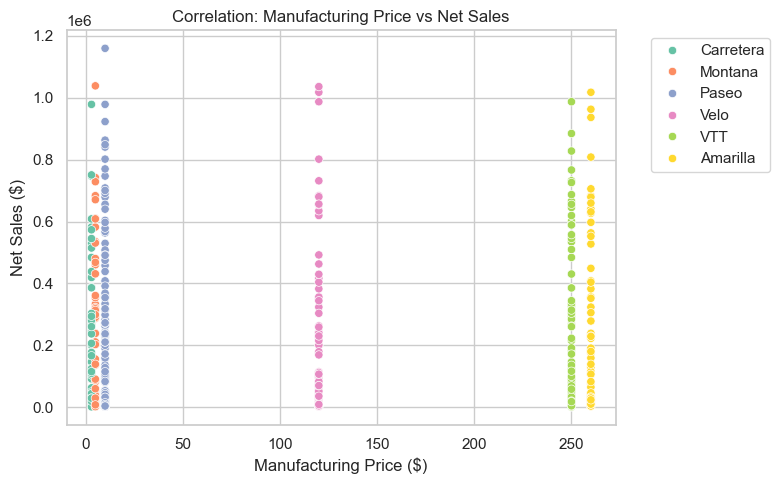

In [8]:
# Visualization 1:
# Manufacturing Price vs Net Sales
plt.figure(figsize = (8, 5))
sns.scatterplot(data = df, x = "Manufacturing Price", y = "Sales", hue = "Product", palette = "Set2")
plt.title("Correlation: Manufacturing Price vs Net Sales")
plt.xlabel("Manufacturing Price ($)")
plt.ylabel("Net Sales ($)")
plt.legend(bbox_to_anchor = (1.05, 1), loc = "upper left")

plt.tight_layout()
plt.show()

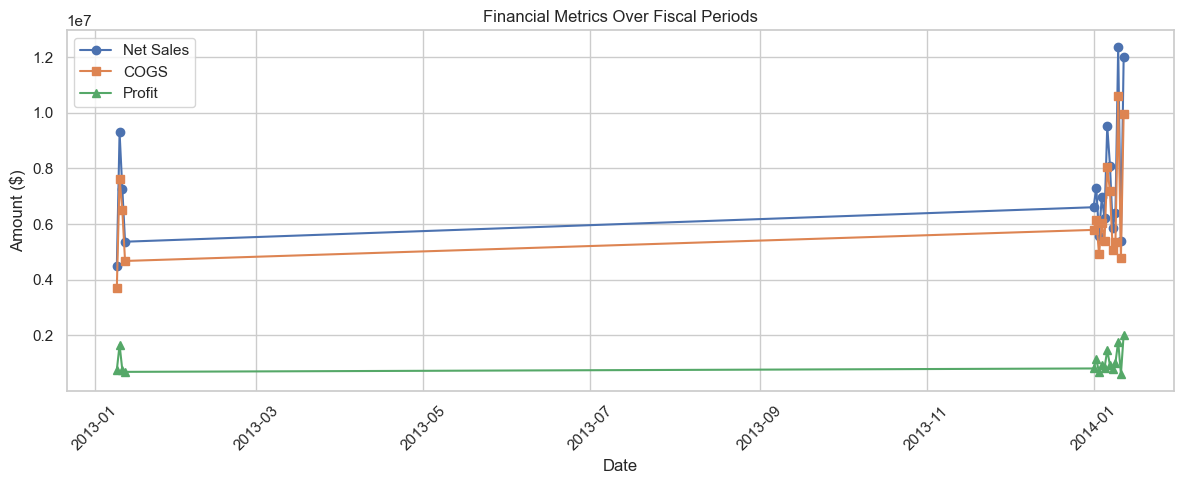

In [13]:
# Visualization 2:
# Trends over Time
monthly_trend = df.sort_values("Date").groupby("Date")[["Profit", "COGS", "Sales"]].sum().reset_index()

monthly_trend = monthly_trend.sort_values("Date")

plt.figure(figsize = (12, 5))
plt.plot(monthly_trend["Date"], monthly_trend["Sales"], label = "Net Sales", marker = "o")
plt.plot(monthly_trend["Date"], monthly_trend["COGS"], label = "COGS", marker = "s")
plt.plot(monthly_trend["Date"], monthly_trend["Profit"], label = "Profit", marker = "^")
plt.title("Financial Metrics Over Fiscal Periods")
plt.xlabel("Date")
plt.ylabel("Amount ($)")
plt.legend()
plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

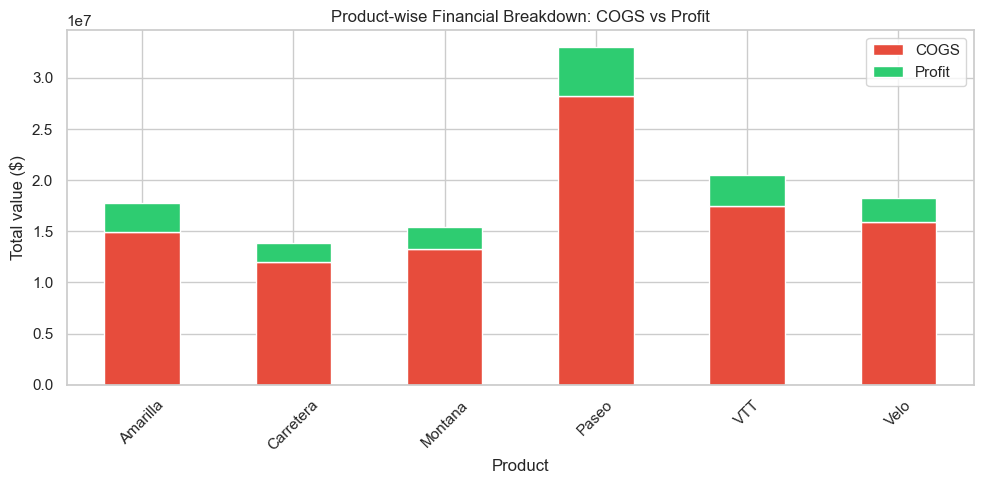

In [10]:
# Grouping data by product to compare COGS and Profit side-by-side
product_financials = df.groupby("Product")[["COGS", "Profit"]].sum().reset_index()

# Creating a stacked bar plot
product_financials.set_index("Product").plot(kind = "bar", stacked = True, figsize = (10, 5), color = ["#e74c3c", "#2ecc71"])
plt.title("Product-wise Financial Breakdown: COGS vs Profit")
plt.xlabel("Product")
plt.ylabel("Total value ($)")
plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

In [11]:
# Calculating overall high-level stats for your final findings report
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
margin = (total_profit / total_sales) * 100

print("---Project Executive Summary and Findings---")
print(f"1. Total Net Sales Captured: ${total_sales:,.2f}")
print(f"2. Total Profit Generated: ${total_profit:,.2f}")
print(f"3. Overall Calculated Profit Margin: {margin:,.2f}%")

print("\nConclusion for Assignment:")
print("Our analysis successfully addresses the research questions. Visualizations show clear")
print("seasonal trends across fiscal periods, while the product breakdown reveals that specific")
print("high-COGS product lines significantly impact overall profit margins.")

---Project Executive Summary and Findings---
1. Total Net Sales Captured: $118,726,350.26
2. Total Profit Generated: $16,893,702.26
3. Overall Calculated Profit Margin: 14.23%

Conclusion for Assignment:
Our analysis successfully addresses the research questions. Visualizations show clear
seasonal trends across fiscal periods, while the product breakdown reveals that specific
high-COGS product lines significantly impact overall profit margins.
